In [1]:
import matplotlib.pyplot as plt

from causal_gym.envs.highway import HighwayPCH
from causal_gym.core import Task

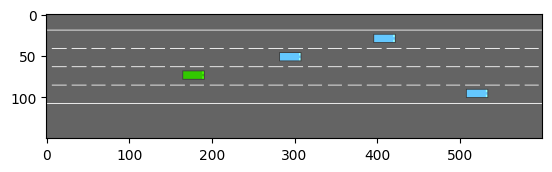

In [2]:
num_steps = 2
pch = HighwayPCH(num_steps=num_steps, render_mode='rgb_array', perception='truth', u_prob=.5, task=Task(learning_regime='cool'))
state, info = pch.reset()
obs = pch.render()
# obs.shape
plt.imshow(obs)

Though there are more variables and more complex causal diagrams in the sequential highway problem, 
the crux of the setting is still about whether we can find a good proxy for the imitator when certain
information is not accessible.

The variables are,
- $D_t$: whether the vehicle in front is too close.
- $L_t$: ego vehicle’s current lane.
- $A_t$, $B_t$: whether the left and right lanes are open, respectively.
- $W_t$: whether the dashboard warning sign is on.
- $I_t$: whether the front car’s brake light is on.
- $U_t$: foggy weather.

For the expert policy, it can observe the front car's brake light while for imitator it cannot. Similarly 
as in the single step case, we can allow the imitator to use dashboard warning sign as a proxy to learn
the imitation policy. U_t, the weather condition, here is to add some more randomness to the environment that
would cause the readings of those variables noisy (like front light, lane clear or not). Thus, increasing the 
hardness of the environment.

In [3]:
pch.get_graph

In [4]:
num_steps = 200
pch = HighwayPCH(num_steps=num_steps, render_mode='rgb_array', perception='truth', u_prob=.5, task=Task(learning_regime='see'))

pch.reset()
frames = []
frames.append(pch.render())
for t in range(num_steps):
    obs, reward, terminated, truncated, info = pch.see(show_reward=True)
    frames.append(pch.render())

    if terminated or truncated:
        pch.close()
        break

print([pch.env._meta_actions.ACTIONS_ALL[x] for x in pch.env.X])
print(pch.env.D)
print(pch.env.L)
print(pch.env._I)
print(pch.env.A)
print(pch.env.B)
print(pch.env.W)
print(pch.env._U)
print(pch.env._Y)

['FASTER', 'FASTER', 'FASTER', 'IDLE', 'IDLE', 'FASTER', 'FASTER', 'FASTER', 'FASTER', 'LANE_LEFT', 'LANE_LEFT', 'LANE_LEFT', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'LANE_LEFT', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'IDLE', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'SLOWER', 'FASTER', 'SLOWER', 'SLOWER', 'SL

In [5]:
obs, info = pch.reset()

In [6]:
# run this cell as many times as you want to see step-by-step data
# run above cell to reset
# run below cell to close properly
_, _, _, _, info = pch.see()
pch.render()
print(pch.env._meta_actions.ACTIONS_ALL[info['natural_action']])
print(pch.env.unwrapped.vehicle.lane_index[2])
print(pch.env.L[-1])
print(pch.env.A[-1])
print(pch.env.B[-1])

FASTER
1
1
1
0


In [7]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

def display_frames(frames, figsize=(10, 8), save=False):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            plt.tight_layout()
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            if save:
                # Save the animation as an mp4 file
                anim.save('highway_animation.mp4', fps=4)
            else:
                from IPython.display import HTML
                plt.close(fig) # close the static plot
                display(HTML(anim.to_jshtml()))
                print("Displaying animation.")

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

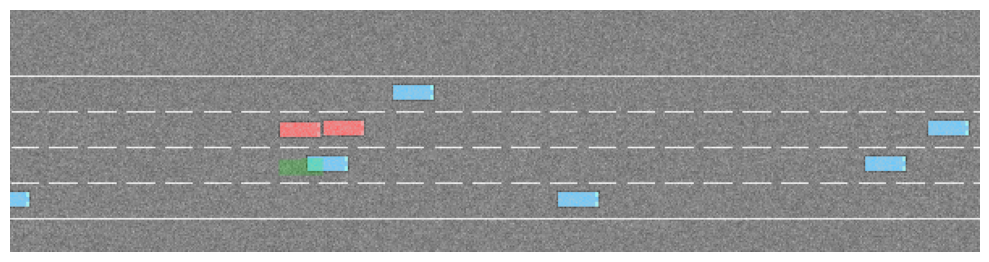

In [8]:
display_frames(frames, save=True)